# Self-Attention: The Foundation of Modern Transformers

This is the seventh and final notebook in the **AI NLP LLM Notes** NLP learning path.

The previous notebooks moved from sparse lexical representations to recurrent sequence models and attention. This notebook concludes the NLP section by introducing **Self-Attention**, the core idea that made modern Transformer architectures and Large Language Models possible.

# Introduction

The NLP journey in this section follows a clear pattern: each method solves a limitation of the previous one.

- **TF-IDF** represented documents with sparse lexical features.
- **Word Vectors** introduced dense semantic spaces.
- **Word Embeddings** learned dense representations from text.
- **RNNs** processed language as an ordered sequence.
- **LSTMs** improved recurrent memory with gates.
- **Attention** helped recurrent models focus on relevant tokens.
- **Self-Attention** removed recurrence and allowed every token to interact directly with every other token.

This notebook builds intuition first, then implements Self-Attention from scratch using NumPy.

In [1]:
import math
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "font.family": "DejaVu Sans",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "xtick.color": "#222222",
        "ytick.color": "#222222",
    }
)

PRIMARY_COLOR = "#2F6F9F"
SECONDARY_COLOR = "#D95F59"
ACCENT_COLOR = "#3A9D7C"
WARNING_COLOR = "#E0A23B"
NEUTRAL_COLOR = "#6B7280"

## NLP Evolution Timeline

The timeline below summarizes the path from lexical matching to modern attention-based architectures.

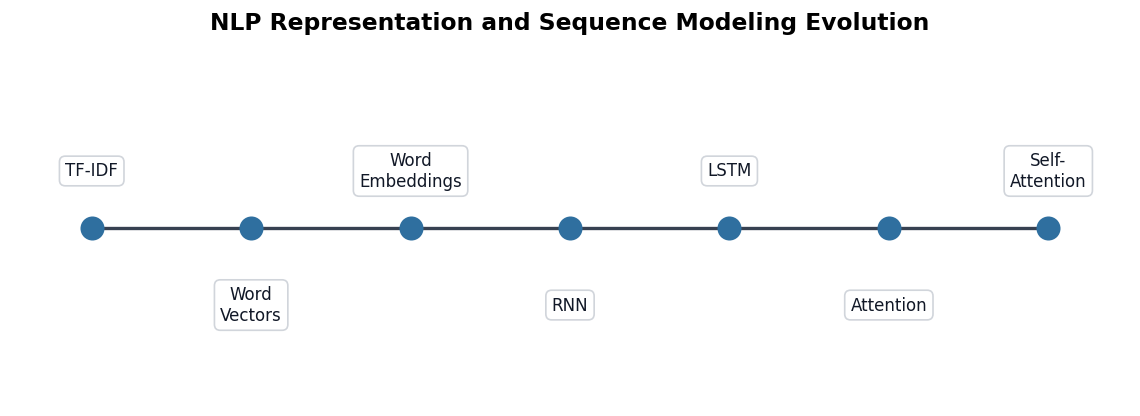

In [3]:
def plot_nlp_evolution_timeline():
    """Plot a compact NLP evolution timeline."""
    stages = [
        "TF-IDF",
        "Word\nVectors",
        "Word\nEmbeddings",
        "RNN",
        "LSTM",
        "Attention",
        "Self-\nAttention",
    ]
    x_positions = np.arange(len(stages))

    fig, ax = plt.subplots(figsize=(12, 3.8))
    ax.plot(x_positions, np.zeros_like(x_positions), color="#374151", linewidth=2)
    ax.scatter(x_positions, np.zeros_like(x_positions), s=180, color=PRIMARY_COLOR, zorder=3)

    for index, stage in enumerate(stages):
        ax.text(
            index,
            0.18 if index % 2 == 0 else -0.24,
            stage,
            ha="center",
            va="center",
            fontsize=10,
            color="#111827",
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": "#D1D5DB",
            },
        )

    ax.set_title("NLP Representation and Sequence Modeling Evolution", pad=14)
    ax.set_xlim(-0.5, len(stages) - 0.5)
    ax.set_ylim(-0.55, 0.55)
    ax.axis("off")
    plt.show()


plot_nlp_evolution_timeline()

## Why Attention Was Still Not Enough

The previous notebook introduced attention on top of recurrent models. That helped models focus on relevant tokens, but it did not remove the recurrent backbone.

Recurrent processing still has limitations:

- tokens are processed sequentially,
- training is harder to parallelize,
- long sequences are slow,
- scaling to very large datasets and models is inefficient.

Researchers wanted to remove recurrence entirely while keeping the ability to model relationships between tokens. Self-Attention provides that shift.

## The Big Idea Behind Self-Attention

Instead of reading one word after another, Self-Attention lets every word directly communicate with every other word.

Classroom analogy: imagine each student can ask every other student for relevant information before answering a question. They do not need to pass the message around the room one person at a time.

Sentence example:

`The student who won the competition thanked her teacher.`

Useful interactions include:

- `student` with `her`,
- `student` with `thanked`,
- `competition` with `won`,
- `teacher` with `thanked`.

Self-Attention learns these token-to-token relationships directly.

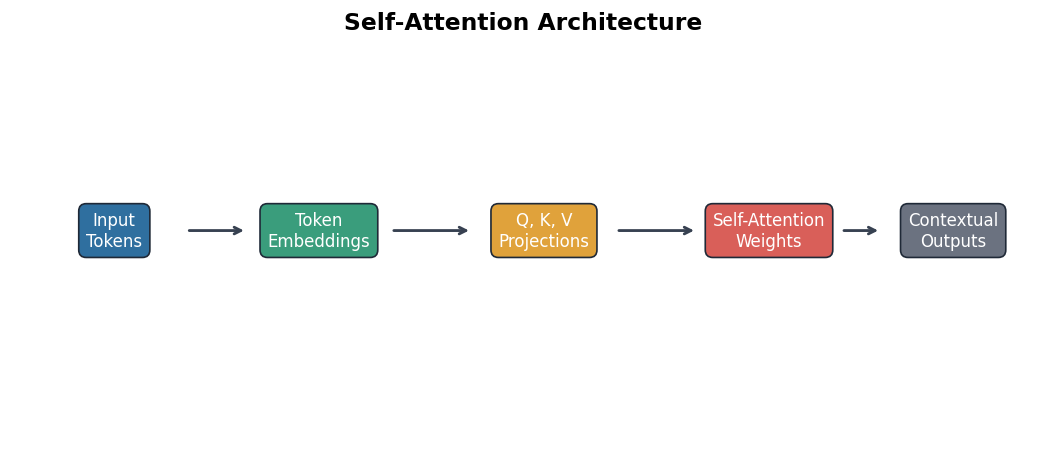

In [4]:
def draw_self_attention_architecture():
    """Draw a high-level Self-Attention architecture diagram."""
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.axis("off")

    nodes = [
        ("Input\nTokens", 0.10, PRIMARY_COLOR),
        ("Token\nEmbeddings", 0.30, ACCENT_COLOR),
        ("Q, K, V\nProjections", 0.52, WARNING_COLOR),
        ("Self-Attention\nWeights", 0.74, SECONDARY_COLOR),
        ("Contextual\nOutputs", 0.92, NEUTRAL_COLOR),
    ]

    for label, x_position, color in nodes:
        ax.text(
            x_position,
            0.55,
            label,
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": color,
                "edgecolor": "#1F2937",
            },
        )

    for (_, start, _), (_, end, _) in zip(nodes[:-1], nodes[1:]):
        ax.annotate(
            "",
            xy=(end - 0.07, 0.55),
            xytext=(start + 0.07, 0.55),
            arrowprops={"arrowstyle": "->", "lw": 1.7, "color": "#374151"},
        )

    ax.set_title("Self-Attention Architecture", pad=16)
    plt.show()


draw_self_attention_architecture()

## Query, Key and Value

Self-Attention uses three learned views of each token:

- **Query**: what this token is looking for,
- **Key**: what this token offers for matching,
- **Value**: the information this token contributes.

Every token creates its own query, key, and value. Attention scores come from comparing queries with keys. The final output is a weighted combination of values.

Mathematically:

\[
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

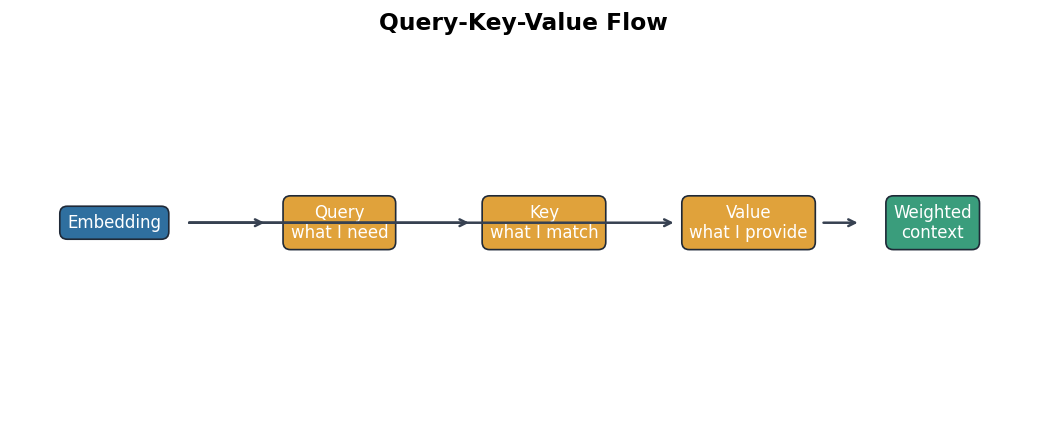

In [5]:
def draw_qkv_flow():
    """Draw Query-Key-Value flow for Self-Attention."""
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    nodes = [
        ("Embedding", 0.10, PRIMARY_COLOR),
        ("Query\nwhat I need", 0.32, WARNING_COLOR),
        ("Key\nwhat I match", 0.52, WARNING_COLOR),
        ("Value\nwhat I provide", 0.72, WARNING_COLOR),
        ("Weighted\ncontext", 0.90, ACCENT_COLOR),
    ]

    for label, x_position, color in nodes:
        ax.text(
            x_position,
            0.55,
            label,
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": color,
                "edgecolor": "#1F2937",
            },
        )

    for start, end in [(0.10, 0.32), (0.10, 0.52), (0.10, 0.72), (0.72, 0.90)]:
        ax.annotate(
            "",
            xy=(end - 0.07, 0.55),
            xytext=(start + 0.07, 0.55),
            arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#374151"},
        )

    ax.set_title("Query-Key-Value Flow", pad=16)
    plt.show()


draw_qkv_flow()

## Implementing Self-Attention From Scratch

We will implement scaled dot-product Self-Attention using only NumPy.

Pipeline:

`Input Embeddings → Weight Matrices → Queries → Keys → Values → Attention Scores → Scaling → Softmax → Weighted Sum`

The implementation is educational rather than optimized.

In [6]:
def tokenize(sentence):
    """Lowercase, remove punctuation, and split a sentence into tokens."""
    cleaned_sentence = sentence.lower().translate(
        str.maketrans("", "", string.punctuation)
    )
    return cleaned_sentence.split()


def softmax(matrix, axis=-1):
    """Compute a numerically stable softmax over a matrix axis."""
    shifted_matrix = matrix - np.max(matrix, axis=axis, keepdims=True)
    exp_matrix = np.exp(shifted_matrix)
    return exp_matrix / np.sum(exp_matrix, axis=axis, keepdims=True)


def create_demo_embeddings(tokens, embedding_dim=4):
    """Create deterministic token embeddings for an educational example."""
    token_vectors = {}
    for index, token in enumerate(dict.fromkeys(tokens)):
        base = np.array(
            [
                math.sin(index + 1),
                math.cos(index + 1),
                (index + 1) / 10,
                ((index + 1) ** 2) / 100,
            ]
        )
        token_vectors[token] = base[:embedding_dim]
    return np.array([token_vectors[token] for token in tokens])


def initialize_attention_weights(embedding_dim, projection_dim):
    """Create deterministic projection matrices for Q, K, and V."""
    rng = np.random.default_rng(RANDOM_SEED)
    return {
        "W_q": rng.normal(0, 0.4, size=(embedding_dim, projection_dim)),
        "W_k": rng.normal(0, 0.4, size=(embedding_dim, projection_dim)),
        "W_v": rng.normal(0, 0.4, size=(embedding_dim, projection_dim)),
    }

In [7]:
def compute_self_attention(embeddings, weights, use_scaling=True):
    """Compute Self-Attention and return all intermediate matrices."""
    queries = embeddings @ weights["W_q"]
    keys = embeddings @ weights["W_k"]
    values = embeddings @ weights["W_v"]
    raw_scores = queries @ keys.T

    scaling_factor = math.sqrt(keys.shape[1]) if use_scaling else 1.0
    scaled_scores = raw_scores / scaling_factor
    attention_weights = softmax(scaled_scores, axis=1)
    outputs = attention_weights @ values

    return {
        "embeddings": embeddings,
        "queries": queries,
        "keys": keys,
        "values": values,
        "raw_scores": raw_scores,
        "scaled_scores": scaled_scores,
        "attention_weights": attention_weights,
        "outputs": outputs,
    }

## Mini Educational Example

We will use the sentence:

`The cat sat on the mat.`

Every token will attend to every other token, producing a token-to-token attention matrix.

In [8]:
sentence = "The cat sat on the mat."
tokens = tokenize(sentence)
embeddings = create_demo_embeddings(tokens, embedding_dim=4)
attention_weights_config = initialize_attention_weights(
    embedding_dim=embeddings.shape[1],
    projection_dim=4,
)
attention_result = compute_self_attention(
    embeddings,
    attention_weights_config,
    use_scaling=True,
)

print(tokens)

['the', 'cat', 'sat', 'on', 'the', 'mat']


## Step-by-Step Matrix Visualization

Each matrix below corresponds to a stage in the Self-Attention computation. Displaying the intermediate matrices makes the mechanism less mysterious.

In [9]:
def matrix_to_dataframe(matrix, row_labels, column_prefix):
    """Convert a matrix into a labeled DataFrame."""
    return pd.DataFrame(
        matrix,
        index=row_labels,
        columns=[f"{column_prefix}_{index + 1}" for index in range(matrix.shape[1])],
    )


display(matrix_to_dataframe(attention_result["embeddings"], tokens, "embed").round(3))

,embed_1,embed_2,embed_3,embed_4
the,0.841,0.540,0.1,0.01
cat,0.909,-0.416,0.2,0.04
sat,0.141,-0.990,0.3,0.09
on,-0.757,-0.654,0.4,0.16
the,0.841,0.540,0.1,0.01
mat,-0.959,0.284,0.5,0.25


In [10]:
display(matrix_to_dataframe(attention_result["queries"], tokens, "q").round(3))
display(matrix_to_dataframe(attention_result["keys"], tokens, "k").round(3))
display(matrix_to_dataframe(attention_result["values"], tokens, "v").round(3))

,q_1,q_2,q_3,q_4
the,-0.320,-0.661,0.317,0.276
cat,0.435,-0.212,0.330,0.443
sat,0.790,0.395,0.114,0.241
on,0.419,0.591,-0.090,-0.133
the,-0.320,-0.661,0.317,0.276
mat,-0.335,0.193,-0.051,-0.327


,k_1,k_2,k_3,k_4
the,0.069,-0.482,0.590,-0.037
cat,0.137,-0.257,0.193,0.030
sat,0.057,0.189,-0.294,0.088
on,-0.105,0.440,-0.363,0.088
the,0.069,-0.482,0.590,-0.037
mat,-0.207,0.263,0.122,0.034


,v_1,v_2,v_3,v_4
the,-0.167,-0.433,0.006,0.531
cat,-0.106,-0.109,0.322,0.324
sat,0.110,0.360,0.313,-0.158
on,0.311,0.567,-0.022,-0.460
the,-0.167,-0.433,0.006,0.531
mat,0.344,0.347,-0.376,-0.290


In [11]:
raw_score_df = pd.DataFrame(
    attention_result["raw_scores"],
    index=[f"query: {token}" for token in tokens],
    columns=[f"key: {token}" for token in tokens],
)
scaled_score_df = pd.DataFrame(
    attention_result["scaled_scores"],
    index=[f"query: {token}" for token in tokens],
    columns=[f"key: {token}" for token in tokens],
)
attention_weight_df = pd.DataFrame(
    attention_result["attention_weights"],
    index=[f"query: {token}" for token in tokens],
    columns=[f"key: {token}" for token in tokens],
)

display(raw_score_df.round(3))
display(scaled_score_df.round(3))
display(attention_weight_df.round(3))

,key: the,key: cat,key: sat,key: on,key: the,key: mat
query: the,0.474,0.195,-0.212,-0.348,0.474,-0.060
query: cat,0.310,0.191,-0.073,-0.220,0.310,-0.090
query: sat,-0.078,0.036,0.108,0.070,-0.078,-0.037
query: on,-0.304,-0.116,0.150,0.237,-0.304,0.053
query: the,0.474,0.195,-0.212,-0.348,0.474,-0.060
query: mat,-0.134,-0.115,0.003,0.110,-0.134,0.103


,key: the,key: cat,key: sat,key: on,key: the,key: mat
query: the,0.237,0.098,-0.106,-0.174,0.237,-0.030
query: cat,0.155,0.096,-0.036,-0.110,0.155,-0.045
query: sat,-0.039,0.018,0.054,0.035,-0.039,-0.019
query: on,-0.152,-0.058,0.075,0.118,-0.152,0.027
query: the,0.237,0.098,-0.106,-0.174,0.237,-0.030
query: mat,-0.067,-0.058,0.002,0.055,-0.067,0.051


,key: the,key: cat,key: sat,key: on,key: the,key: mat
query: the,0.200,0.174,0.142,0.132,0.200,0.153
query: cat,0.187,0.176,0.154,0.143,0.187,0.153
query: sat,0.160,0.169,0.175,0.172,0.160,0.163
query: on,0.146,0.160,0.183,0.191,0.146,0.174
query: the,0.200,0.174,0.142,0.132,0.200,0.153
query: mat,0.158,0.159,0.169,0.178,0.158,0.178


In [12]:
output_df = matrix_to_dataframe(attention_result["outputs"], tokens, "output")
display(output_df.round(3))

,output_1,output_2,output_3,output_4
the,0.024,-0.013,0.042,0.141
cat,0.033,0.009,0.047,0.121
sat,0.058,0.061,0.046,0.070
on,0.074,0.091,0.041,0.039
the,0.024,-0.013,0.042,0.141
mat,0.066,0.070,0.035,0.059


## Visualizing Attention

The attention matrix shows how much each query token attends to each key token. Rows usually sum to 1 because softmax converts scores into probabilities.

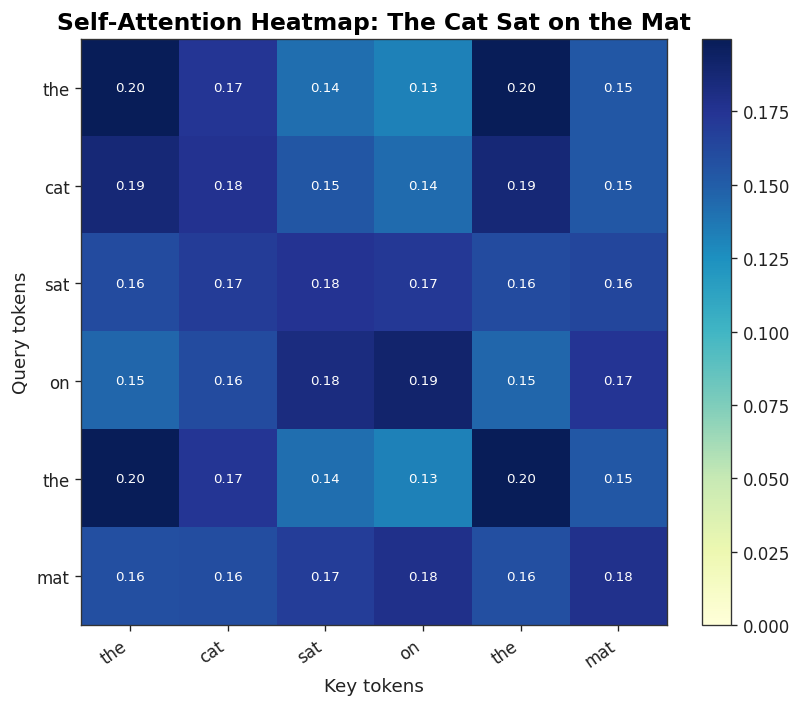

In [13]:
def plot_attention_heatmap(attention_matrix, tokens, title):
    """Plot a token-to-token attention heatmap."""
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(attention_matrix, cmap="YlGnBu", vmin=0, vmax=attention_matrix.max())
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel("Key tokens")
    ax.set_ylabel("Query tokens")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=35, ha="right")
    ax.set_yticklabels(tokens)

    for row in range(attention_matrix.shape[0]):
        for column in range(attention_matrix.shape[1]):
            value = attention_matrix[row, column]
            text_color = "white" if value > attention_matrix.max() / 2 else "#111827"
            ax.text(column, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

    plt.tight_layout()
    plt.show()


plot_attention_heatmap(
    attention_result["attention_weights"],
    tokens,
    "Self-Attention Heatmap: The Cat Sat on the Mat",
)

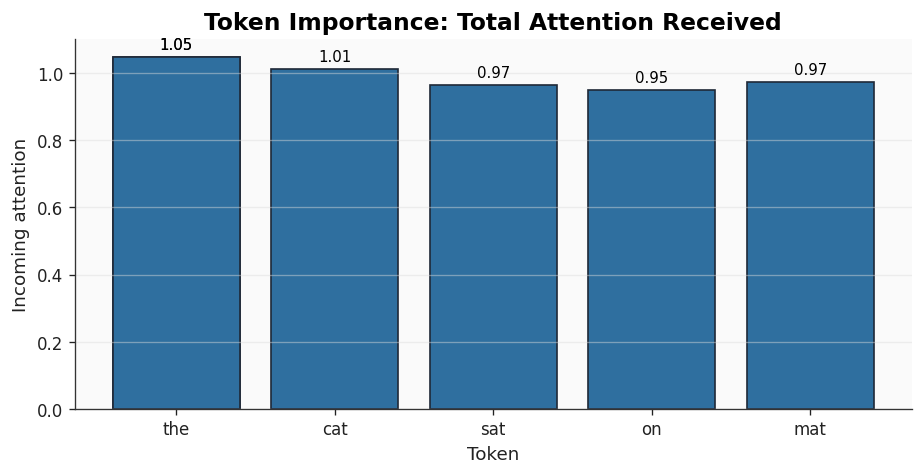

In [14]:
def plot_token_interaction_matrix(attention_matrix, tokens):
    """Plot total attention received by each token."""
    incoming_attention = attention_matrix.sum(axis=0)
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(tokens, incoming_attention, color=PRIMARY_COLOR, edgecolor="#1F2937")
    ax.set_title("Token Importance: Total Attention Received")
    ax.set_xlabel("Token")
    ax.set_ylabel("Incoming attention")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.45)
    plt.show()


plot_token_interaction_matrix(attention_result["attention_weights"], tokens)

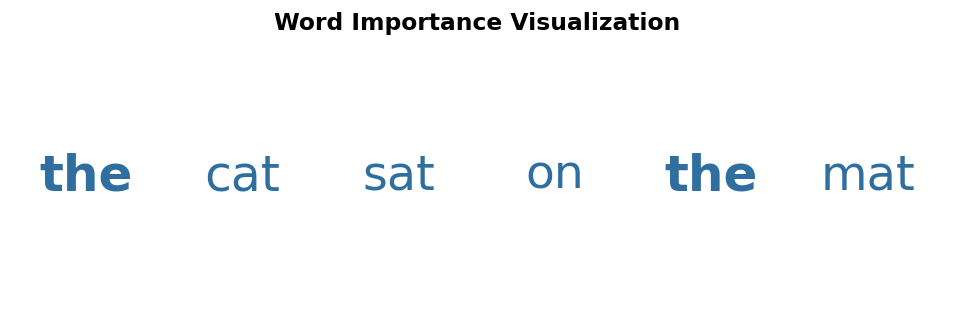

In [15]:
def plot_word_importance(tokens, attention_matrix):
    """Display words with size proportional to incoming attention."""
    incoming_attention = attention_matrix.sum(axis=0)
    max_attention = incoming_attention.max()
    x_positions = np.linspace(0.08, 0.92, len(tokens))

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    for token, importance, x_position in zip(tokens, incoming_attention, x_positions):
        font_size = 12 + 18 * (importance / max_attention)
        ax.text(
            x_position,
            0.55,
            token,
            ha="center",
            va="center",
            fontsize=font_size,
            color=PRIMARY_COLOR,
            weight="bold" if importance == max_attention else "normal",
        )
    ax.set_title("Word Importance Visualization", pad=18)
    plt.show()


plot_word_importance(tokens, attention_result["attention_weights"])

## Why Scaling Matters

Dot products can become large when the key/query dimension grows. Large scores make softmax overly sharp, meaning one token may dominate too strongly.

Scaled dot-product attention divides scores by:

\[
\sqrt{d_k}
\]

This keeps score magnitudes more stable.

In [16]:
attention_without_scaling = compute_self_attention(
    embeddings,
    attention_weights_config,
    use_scaling=False,
)

scaling_comparison_df = pd.DataFrame(
    {
        "token": tokens,
        "max_weight_without_scaling": attention_without_scaling["attention_weights"].max(axis=1),
        "max_weight_with_scaling": attention_result["attention_weights"].max(axis=1),
    }
)

display(scaling_comparison_df.round(3))

,token,max_weight_without_scaling,max_weight_with_scaling
0,the,0.233,0.200
1,cat,0.207,0.187
2,sat,0.184,0.175
3,on,0.217,0.191
4,the,0.233,0.200
5,mat,0.190,0.178


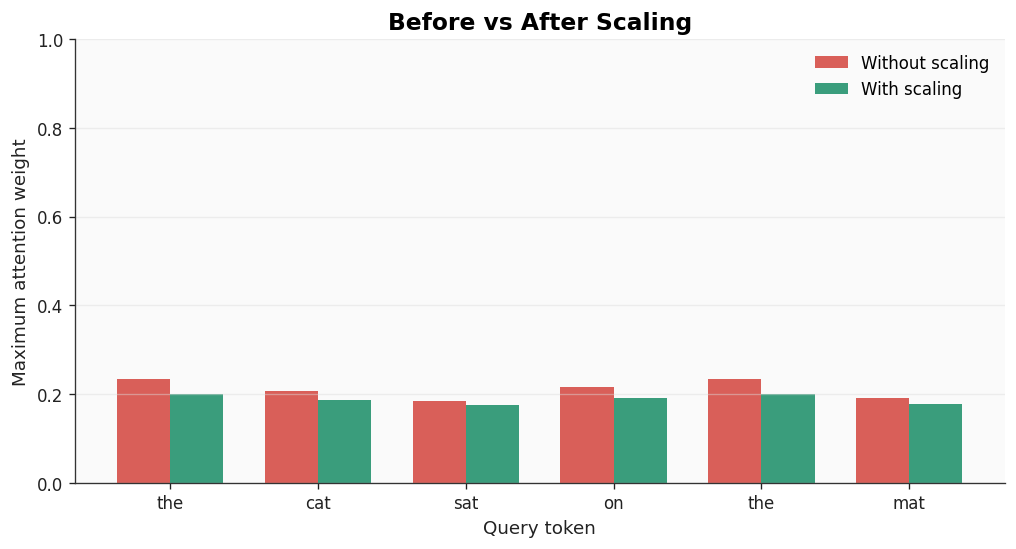

In [17]:
def plot_scaling_comparison(comparison_df):
    """Plot maximum attention concentration before and after scaling."""
    x_positions = np.arange(len(comparison_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.bar(
        x_positions - width / 2,
        comparison_df["max_weight_without_scaling"],
        width,
        label="Without scaling",
        color=SECONDARY_COLOR,
    )
    ax.bar(
        x_positions + width / 2,
        comparison_df["max_weight_with_scaling"],
        width,
        label="With scaling",
        color=ACCENT_COLOR,
    )
    ax.set_title("Before vs After Scaling")
    ax.set_xlabel("Query token")
    ax.set_ylabel("Maximum attention weight")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(comparison_df["token"])
    ax.set_ylim(0, 1)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.45)
    plt.show()


plot_scaling_comparison(scaling_comparison_df)

## Self-Attention vs Previous Methods

Self-Attention is not just another representation technique. It changes how tokens exchange information.

In [18]:
comparison_table = pd.DataFrame(
    {
        "Method": [
            "TF-IDF",
            "Word Vectors",
            "Word Embeddings",
            "RNN",
            "LSTM",
            "Attention",
            "Self-Attention",
        ],
        "Captures Semantics": ["Low", "Medium", "High", "High", "High", "High", "High"],
        "Captures Order": ["No", "No", "No", "Yes", "Yes", "Yes", "With position info"],
        "Parallelizable": ["High", "High", "High", "Low", "Low", "Medium", "High"],
        "Context Aware": ["No", "No", "No", "Limited", "Limited", "Better", "Strong"],
        "Long Dependencies": ["Weak", "Weak", "Weak", "Weak", "Medium", "Good", "Strong"],
        "Scalability": ["High", "High", "High", "Medium", "Medium", "Medium", "Very High"],
    }
)

display(comparison_table)

,Method,Captures Semantics,Captures Order,Parallelizable,Context Aware,Long Dependencies,Scalability
0,TF-IDF,Low,No,High,No,Weak,High
1,Word Vectors,Medium,No,High,No,Weak,High
2,Word Embeddings,High,No,High,No,Weak,High
3,RNN,High,Yes,Low,Limited,Weak,Medium
4,LSTM,High,Yes,Low,Limited,Medium,Medium
5,Attention,High,Yes,Medium,Better,Good,Medium
6,Self-Attention,High,With position info,High,Strong,Strong,Very High


## Computational Complexity

RNN and LSTM models process tokens step by step. This makes them naturally sequential.

Self-Attention compares every token with every other token. That is more parallelizable, but it creates a quadratic cost with sequence length.

For short and medium sequences, this tradeoff is powerful. For very long sequences, memory and compute become major engineering challenges.

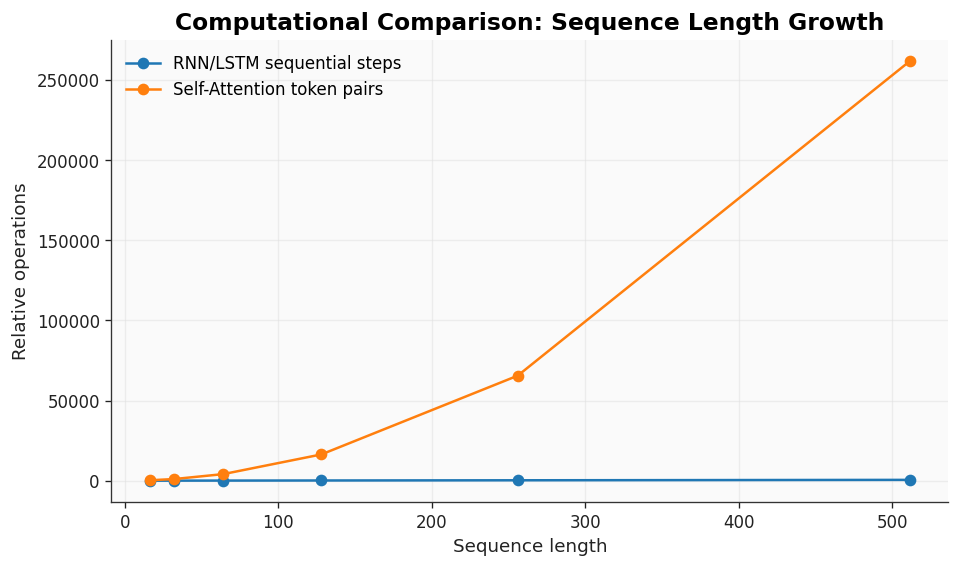

In [19]:
def plot_computational_comparison():
    """Plot intuitive computation growth for recurrent and attention models."""
    sequence_lengths = np.array([16, 32, 64, 128, 256, 512])
    recurrent_steps = sequence_lengths
    self_attention_pairs = sequence_lengths**2

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(sequence_lengths, recurrent_steps, marker="o", label="RNN/LSTM sequential steps")
    ax.plot(sequence_lengths, self_attention_pairs, marker="o", label="Self-Attention token pairs")
    ax.set_title("Computational Comparison: Sequence Length Growth")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Relative operations")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()


plot_computational_comparison()

## Mini Project: Tiny Self-Attention Visualizer

The function below accepts a custom sentence and returns:

- tokenized words,
- attention matrix,
- heatmap,
- attention scores,
- most influential words.

In [20]:
def run_self_attention_visualizer(sentence, embedding_dim=4, projection_dim=4):
    """Run Self-Attention on a custom sentence and return analysis artifacts."""
    custom_tokens = tokenize(sentence)
    custom_embeddings = create_demo_embeddings(custom_tokens, embedding_dim=embedding_dim)
    custom_weights = initialize_attention_weights(
        embedding_dim=embedding_dim,
        projection_dim=projection_dim,
    )
    result = compute_self_attention(custom_embeddings, custom_weights, use_scaling=True)
    attention_matrix = result["attention_weights"]
    incoming_attention = attention_matrix.sum(axis=0)

    importance_df = (
        pd.DataFrame(
            {
                "token": custom_tokens,
                "incoming_attention": incoming_attention,
            }
        )
        .sort_values("incoming_attention", ascending=False)
        .reset_index(drop=True)
    )

    attention_df = pd.DataFrame(
        attention_matrix,
        index=[f"query: {token}" for token in custom_tokens],
        columns=[f"key: {token}" for token in custom_tokens],
    )

    return {
        "tokens": custom_tokens,
        "attention_matrix": attention_matrix,
        "attention_df": attention_df,
        "importance_df": importance_df,
    }

In [21]:
custom_sentence = "The student thanked her teacher after winning the competition"
visualizer_result = run_self_attention_visualizer(custom_sentence)

display(visualizer_result["attention_df"].round(3))
display(visualizer_result["importance_df"].round(3))

,key: the,key: student,key: thanked,key: her,key: teacher,key: after,key: winning,key: the,key: competition
query: the,0.123,0.107,0.088,0.082,0.095,0.120,0.136,0.123,0.125
query: student,0.118,0.111,0.097,0.091,0.097,0.113,0.128,0.118,0.127
query: thanked,0.107,0.113,0.118,0.115,0.109,0.106,0.108,0.107,0.116
query: her,0.101,0.111,0.127,0.133,0.121,0.104,0.097,0.101,0.104
query: teacher,0.107,0.108,0.114,0.120,0.120,0.113,0.106,0.107,0.105
query: after,0.118,0.104,0.091,0.092,0.105,0.124,0.130,0.118,0.118
query: winning,0.124,0.102,0.078,0.073,0.091,0.126,0.149,0.124,0.132
query: the,0.123,0.107,0.088,0.082,0.095,0.120,0.136,0.123,0.125
query: competition,0.121,0.104,0.082,0.076,0.090,0.121,0.146,0.121,0.138


,token,incoming_attention
0,winning,1.138
1,competition,1.091
2,after,1.048
3,the,1.044
4,the,1.044
5,student,0.968
6,teacher,0.922
7,thanked,0.883
8,her,0.863


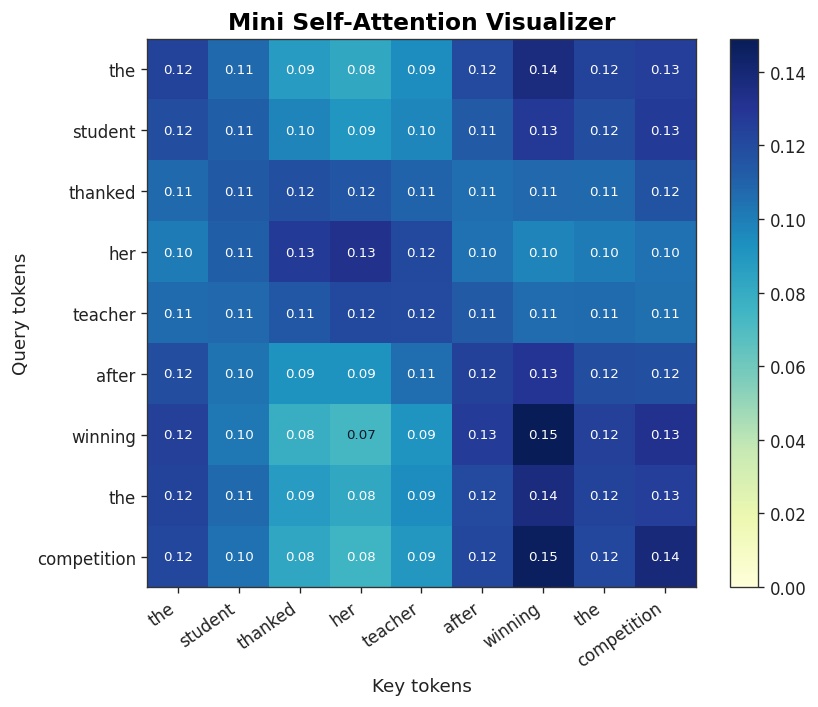

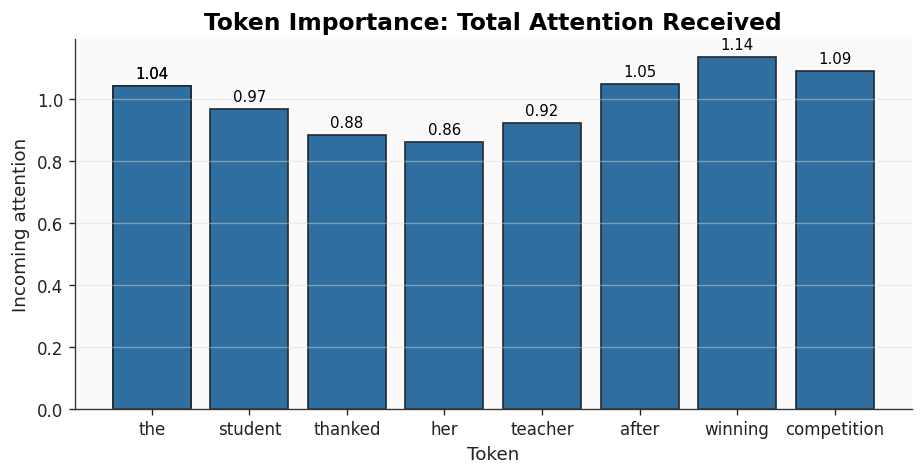

In [22]:
plot_attention_heatmap(
    visualizer_result["attention_matrix"],
    visualizer_result["tokens"],
    "Mini Self-Attention Visualizer",
)
plot_token_interaction_matrix(
    visualizer_result["attention_matrix"],
    visualizer_result["tokens"],
)

## Advantages

Self-Attention became foundational because it provides:

- **parallel computation** across tokens,
- **global context** because every token can attend to every other token,
- **long-range dependency handling** without recurrent chains,
- **interpretability signals** through attention matrices,
- **Transformer foundation** for modern language models.

## Limitations

Self-Attention also has real engineering costs:

- **quadratic complexity** with sequence length,
- high **memory consumption** for long contexts,
- challenges with very long documents,
- need for positional information because attention alone does not know token order.

Later methods such as Flash Attention and efficient Transformer variants were introduced to make attention faster and more memory-efficient.

## Real-world Applications

Self-Attention powers or influences many modern systems and tasks:

- ChatGPT,
- BERT,
- GPT,
- Gemini,
- Claude,
- translation,
- summarization,
- semantic search,
- RAG,
- question answering,
- code generation.

## From Self-Attention to Transformers

Self-Attention is only one building block. Transformer architectures also include:

- **Multi-Head Attention**: multiple attention views in parallel,
- **Positional Encoding**: information about token order,
- **Feed Forward Networks**: per-token transformations after attention,
- **Residual Connections**: stable information flow,
- **Layer Normalization**: more stable training.

The next section will combine these components into full Transformer architecture.

## Final Summary

This notebook concluded the NLP learning path by showing why Self-Attention changed the direction of modern NLP.

Key takeaways:

- NLP evolved from sparse lexical matching to contextual token interaction.
- Recurrent models handle order but are hard to parallelize.
- Attention helps models focus, but recurrent attention still depends on sequential processing.
- Self-Attention lets every token interact directly with every other token.
- Modern LLMs rely on Self-Attention because it scales, captures global context, and supports Transformer architectures.

## Next Section

🚀 Next: Large Language Models (LLMs)

The upcoming notebooks will cover:

- Transformer Architecture,
- LLM Training Pipeline,
- Small Language Models,
- Inference,
- Quantization,
- Fine-Tuning,
- RLHF,
- Serving,
- Evaluation,
- Deployment.